# Library

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993222 sha256=8a9b8b02e30af77833c88e1ce07b06e08eb89c0a183f5d033ba304a79c93b370
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
import os
import shutil
import zipfile
import pandas as pd

os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'

!kaggle datasets download -d aksharagadwe/abbreviations-and-slangs-for-text-preprocessing -p /content
destination_path = "/content/abbreviations-and-slangs-for-text-preprocessing"
os.makedirs(destination_path, exist_ok=True)
shutil.move("/content/abbreviations-and-slangs-for-text-preprocessing.zip", destination_path)

with zipfile.ZipFile(os.path.join(destination_path, 'abbreviations-and-slangs-for-text-preprocessing.zip'), 'r') as zip_ref:
    all_files = zip_ref.namelist()
    abbreviation_files = [f for f in all_files if 'abbreviation' in f.lower()]
    for file in abbreviation_files:
        zip_ref.extract(file, destination_path)

Dataset URL: https://www.kaggle.com/datasets/aksharagadwe/abbreviations-and-slangs-for-text-preprocessing
License(s): unknown
  0% 0.00/1.14k [00:00<?, ?B/s]
100% 1.14k/1.14k [00:00<00:00, 3.02MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import spacy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import unicodedata
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import gensim
from gensim.models import Word2Vec
from wordcloud import WordCloud

from nltk.stem import PorterStemmer
from textblob import TextBlob

nltk.download("vader_lexicon")
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

# Data Understading

## Data FC24

In [ ]:
df_fc24= pd.read_csv('FC_24.csv')
df_fc24.head()

,ReviewText,Review,ReviewLength,PlayHours,DatePosted
0,Like a drug addiction.,Not Recommended,19,47.7 hrs on record,Posted: 14 November
1,EA FIX YOUR DAMN GAME IVE BOUGHT THIS GAME AND...,Not Recommended,95,44.6 hrs on record,Posted: 14 November
2,anticheat many troubleshot,Not Recommended,24,272.0 hrs on record,Posted: 14 November
3,fine,Recommended,4,573.8 hrs on record,Posted: 14 November
4,mnv sycks,Recommended,8,31.3 hrs on record,Posted: 14 November


In [ ]:
df_fc24.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21890 entries, 0 to 21889
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ReviewText    21798 non-null  object
 1   Review        21890 non-null  object
 2   ReviewLength  21890 non-null  int64 
 3   PlayHours     21890 non-null  object
 4   DatePosted    21890 non-null  object
dtypes: int64(1), object(4)
memory usage: 855.2+ KB


In [ ]:
df_fc24.dropna(inplace=True)

## Data FC25

In [ ]:
df_fc25= pd.read_csv('FC_25.csv')
df_fc25.head()

,ReviewText,Review,ReviewLength,PlayHours,DatePosted
0,I do not want to type much because i might be ...,Not Recommended,91,46.5 hrs on record,Posted: 21 November
1,doesnt allow nintendo pro controller for me,Recommended,37,12.7 hrs on record,Posted: 21 November
2,A great way to kill some time :D,Recommended,25,44.6 hrs on record,Posted: 21 November
3,this game is so buns and unrealistic bro ur te...,Not Recommended,420,15.1 hrs on record,Posted: 21 November
4,The game is really bad made... if the game wan...,Not Recommended,243,66.8 hrs on record,Posted: 21 November


In [ ]:
df_fc25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3860 entries, 0 to 3859
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ReviewText    3853 non-null   object
 1   Review        3860 non-null   object
 2   ReviewLength  3860 non-null   int64 
 3   PlayHours     3860 non-null   object
 4   DatePosted    3860 non-null   object
dtypes: int64(1), object(4)
memory usage: 150.9+ KB


In [ ]:
df_fc25.dropna(inplace=True)

# Language Detection

In [ ]:
from langdetect import detect

# Fungsi untuk mendeteksi bahasa
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

# # Tambahkan kolom deteksi bahasa
# df_fc24["Language"] = df_fc24["ReviewText"].apply(detect_language)
# df_fc25["Language"] = df_fc25["ReviewText"].apply(detect_language)

# # Lihat distribusi bahasa
# print(df_fc24["Language"].value_counts())
# print(df_fc25["Language"].value_counts())


In [ ]:
# # Hanya ambil ulasan dalam Bahasa Inggris
# df_fc24 = df_fc24[df_fc24["Language"] == "en"]
# df_fc25 = df_fc25[df_fc25["Language"] == "en"]

In [ ]:
len(df_fc24)
len(df_fc25)

3853

# Prepocessing

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

stops = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_content(content):
    # Mengkonversi teks menjadi huruf kecil
    content = content.lower()

    # Menghapus URL
    content = re.sub(r'http\S+|www\S+|https\S+', '', content, flags=re.MULTILINE)

    # Menghapus HTML tags
    content = re.sub(r'<.*?>', '', content)

    # Menghapus mention (@usernames)
    content = re.sub(r'@\w+', '', content)

    # Menghapus tanda baca dan angka
    content = re.sub(r'[^a-z\s]', '', content)

    # Tokenisasi
    words = content.split()

    # Mengganti karakter yang berulang (contoh: "sooo" -> "so")
    words = [re.sub(r'(.)\1{2,}', r'\1\1', word) for word in words]

    # POS tagging
    pos_tags = pos_tag(words)

    # Lemmatization dengan POS Tagging
    lemmatized_words = []
    for word, tag in pos_tags:
        if word not in stops:
            wordnet_pos = get_wordnet_pos(tag)
            lemmatized_words.append(lemmatizer.lemmatize(word, pos=wordnet_pos))

    cleaned_content = ' '.join(lemmatized_words)

    return cleaned_content


In [ ]:
list_df = [df_fc24, df_fc25]

# for df in list_df:
#     df['ReviewText'] = df['ReviewText'].apply(clean_content)

In [ ]:
# duplicate_fc24 = df_fc24[df_fc24.duplicated()]
# duplicate_fc25 = df_fc25[df_fc25.duplicated()]

# print("Number of duplicate rows in df_fc24:", len(duplicate_fc24))
# print("Number of duplicate rows in df_fc25:", len(duplicate_fc25))

In [ ]:
# # Remove duplicate rows in df_fc24
# df_fc24.drop_duplicates(inplace=True)
# duplicate_fc24 = df_fc24[df_fc24.duplicated()]

# # Remove duplicate rows in df_fc25
# df_fc25.drop_duplicates(inplace=True)
# duplicate_fc25 = df_fc25[df_fc25.duplicated()]

# print("Number of duplicate rows in df_fc24:", len(duplicate_fc24))
# print("Number of duplicate rows in df_fc25:", len(duplicate_fc25))

# Abbrevation Handling

In [ ]:
df_acronyms = pd.read_csv('abbreviations-and-slangs-for-text-preprocessing/Abbreviations and Slang.csv')

acronyms_dict = dict(zip(df_acronyms['Abbreviations'], df_acronyms['Text']))

manual_acronyms = {
    'u': 'you',
    'r': 'are',
    'some1': 'someone',
    'yrs': 'years',
    'hrs': 'hours',
    'mins': 'minutes',
    'secs': 'seconds',
    "ur": "your",
    "pls": "please",
    "thx": "thanks",
    "wont": "will not",
    "im": "i am",
    "idk": "i do not know",
    "gonna": "going to",
    "wanna": "want to",
    "didnt": "did not",
    "doesnt": "does not",
    "dont": "do not",
    "wont": "will not",
    "cant": "cannot",
    "youre": "you are",
    "youve": "you have",
    "youll": "you will",
    "youre": "you are",
    "ive" : "i have",
    "dont": "do not",
    "havent": "have not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "shouldnt": "should not",
    "wouldnt": "would not",
    "couldnt": "could not",
    "aint": "is not",
    "arent": "are not",
    "lmfao": "laugh my freak ass off",
    "lmfaoo": "laugh my freak ass off",
    "lmfaooo": "laugh my freak ass off",
    "lmao": "laugh my freak ass off",
    "ai" : "artificial intelligent",
    "alway":"always",
    'bc' : 'because',
    'bcz': 'because',
    'bcsz': 'because',
    'fk':'fuck'
}

acronyms_dict.update(manual_acronyms)

def replace_acronyms(text, acronyms_dict):
    for acronym, expansion in acronyms_dict.items():
        text = re.sub(r'\b' + re.escape(acronym) + r'\b', expansion, text, flags=re.IGNORECASE)
    return text

In [ ]:
# for df in list_df:
#   df['ReviewText'] = df['ReviewText'].apply(lambda x: replace_acronyms(x, acronyms_dict))

# Vader Labelling

In [ ]:
# from collections import Counter

# def analyze_word_frequency(df, review_column, recommendation_column, category):
#     combined_reviews = " ".join(df[df[recommendation_column] == category][review_column])

#     word_frequency = Counter(combined_reviews.split())

#     return word_frequency

# recommended_words_fc24 = analyze_word_frequency(df_fc24, "ReviewText", "Review", "Recommended")
# not_recommended_words_fc24 = analyze_word_frequency(df_fc24, "ReviewText", "Review", "Not Recommended")

# recommended_words_fc25 = analyze_word_frequency(df_fc25, "ReviewText", "Review", "Recommended")
# not_recommended_words_fc25 = analyze_word_frequency(df_fc25, "ReviewText", "Review", "Not Recommended")

# # Tampilkan hasil
# print("Top words in FIFA 2024 Recommended reviews:")
# print(recommended_words_fc24.most_common(30))

# print("\nTop words in FIFA 2024 Not Recommended reviews:")
# print(not_recommended_words_fc24.most_common(30))

# print("\nTop words in FIFA 2025 Recommended reviews:")
# print(recommended_words_fc25.most_common(30))

# print("\nTop words in FIFA 2025 Not Recommended reviews:")
# print(not_recommended_words_fc25.most_common(30))


In [ ]:
# df_fc24 = df_fc24.dropna()
# df_fc24 = df_fc24[df_fc24['ReviewText'].str.len() > 1]

# df_fc25 = df_fc25.dropna()
# df_fc25= df_fc25[df_fc25['ReviewText'].str.len() > 1]

In [ ]:
def vader_sentiment(data, review_column):
    sentiments = SentimentIntensityAnalyzer()
    data["Positive"] = [sentiments.polarity_scores(i)["pos"] for i in data[review_column]]
    data["Negative"] = [sentiments.polarity_scores(i)["neg"] for i in data[review_column]]
    data["Neutral"] = [sentiments.polarity_scores(i)["neu"] for i in data[review_column]]
    data["Compound"] = [sentiments.polarity_scores(i)["compound"] for i in data[review_column]]

    # Assign sentiment labels
    sentiment_labels = []
    for score in data["Compound"]:
        if score >= 0.05:
            sentiment_labels.append('Positive')
        elif score <= -0.05:
            sentiment_labels.append('Negative')
        else:
            sentiment_labels.append('Neutral')
    data["Sentiment"] = sentiment_labels

    return data

In [ ]:
# df_fc24 = vader_sentiment(df_fc24, "ReviewText")
# df_fc25 = vader_sentiment(df_fc25, "ReviewText")

## Data Asli No Prepo

In [ ]:
df_cek = pd.read_csv('FC_24.csv')
df_cek2 = pd.read_csv('FC_25.csv')

In [ ]:
from langdetect import detect

# Fungsi untuk mendeteksi bahasa
def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Tambahkan kolom deteksi bahasa
df_cek["Language"] = df_cek["ReviewText"].apply(detect_language)
df_cek2["Language"] = df_cek2["ReviewText"].apply(detect_language)

# Lihat distribusi bahasa
print(df_cek["Language"].value_counts())
print(df_cek2["Language"].value_counts())

Language
en         7601
so         1301
unknown     652
tl          478
de          439
pl          336
af          323
cy          307
es          236
da          235
sw          222
no          220
id          212
tr          197
ca          169
ro          159
pt          147
fi          140
vi          135
it          126
nl          125
fr          123
et          117
sl          115
sq          114
sk          111
hr          109
ar           92
hu           54
sv           52
lt           43
lv           35
cs           29
fa           23
th           22
he           12
ru           11
ur           10
ko            8
zh-cn         4
el            3
bg            2
ja            1
mk            1
Name: count, dtype: int64
Language
en         2547
so          216
unknown     171
de           91
tl           62
cy           57
da           49
af           47
sw           46
pl           45
es           38
no           36
pt           32
sq           32
ca           32
vi          

In [ ]:
# Hanya ambil ulasan dalam Bahasa Inggris
df_cek = df_cek[df_cek["Language"] == "en"]
df_cek2 = df_cek2[df_cek2["Language"] == "en"]

In [ ]:
df_cek = vader_sentiment(df_cek, "ReviewText")
df_cek2 = vader_sentiment(df_cek2, "ReviewText")

In [ ]:
df_cek['Sentiment'].value_counts()

,count
Sentiment,
Positive,3493
Negative,2699
Neutral,1409


In [ ]:
df_cek

,ReviewText,Review,ReviewLength,PlayHours,DatePosted,Language,Positive,Negative,Neutral,Compound,Sentiment
0,Like a drug addiction.,Not Recommended,19.0,47.7 hrs on record,Posted: 14 November,en,0.556,0.000,0.444,0.3612,Positive
1,EA FIX YOUR DAMN GAME IVE BOUGHT THIS GAME AND...,Not Recommended,95.0,44.6 hrs on record,Posted: 14 November,en,0.000,0.242,0.758,-0.7506,Negative
2,anticheat many troubleshot,Not Recommended,24.0,272.0 hrs on record,Posted: 14 November,en,0.000,0.000,1.000,0.0000,Neutral
6,worst game ever why did i even make this purch...,Not Recommended,96.0,53.1 hrs on record,Posted: 14 November,en,0.000,0.272,0.728,-0.8481,Negative
7,its my first time playing FC24,Recommended,25.0,5.0 hrs on record,Posted: 14 November,en,0.265,0.000,0.735,0.2023,Positive
...,...,...,...,...,...,...,...,...,...,...,...
14835,its an ea game what do you expect full of ♥♥♥♥...,Recommended,50.0,245.7 hrs on record,Posted: March 31,en,0.348,0.000,0.652,0.7876,Positive
14838,"dont get me wrong, the game itself is very-ver...",Recommended,957.0,321.1 hrs on record,Posted: March 31,en,0.103,0.072,0.824,0.7725,Positive
14839,"BugFC 24, will not be playing anymore",Not Recommended,31.0,319.7 hrs on record,Posted: March 31,en,0.000,0.210,0.790,-0.1511,Negative
14843,"yeaH better than fifa23, 22",Recommended,23.0,49.9 hrs on record,Posted: March 31,en,0.630,0.000,0.370,0.6249,Positive


In [ ]:
# Menampilkan proporsi dalam persen dengan format yang rapi
sentiment_percentage = df_cek['Sentiment'].value_counts(normalize=True).mul(100).round(2)

# Menggabungkan kategori dan persentase menjadi format seperti "Positive: 30%"
formatted_percentage = [f"{sentiment}: {percentage}%" for sentiment, percentage in sentiment_percentage.items()]

# Menampilkan hasil
print(", ".join(formatted_percentage))


Positive: 45.95%, Negative: 35.51%, Neutral: 18.54%


In [ ]:
df_b1 = pd.read_csv('df_fc24_vader_sentiment_inshaa allah fix.csv')
df_b2 = pd.read_csv('df_fc25_vader_sentiment.csv')

In [ ]:
# Menampilkan proporsi dalam persen dengan format yang rapi
sentiment_percentage = df_b1['Sentiment'].value_counts(normalize=True).mul(100).round(2)

# Menggabungkan kategori dan persentase menjadi format seperti "Positive: 30%"
formatted_percentage = [f"{sentiment}: {percentage}%" for sentiment, percentage in sentiment_percentage.items()]

# Menampilkan hasil
print(", ".join(formatted_percentage))


Positive: 49.04%, Negative: 33.12%, Neutral: 17.84%


In [ ]:
df_b1

,ReviewText,Review,ReviewLength,PlayHours,DatePosted,Language,Positive,Negative,Neutral,Compound,Sentiment
0,like drug addiction,Not Recommended,19,47.7 hrs on record,Posted: 14 November,en,0.556,0.000,0.444,0.3612,Positive
1,ea fix damn game i have buy game does not work...,Not Recommended,95,44.6 hrs on record,Posted: 14 November,en,0.123,0.127,0.750,-0.0186,Neutral
2,anticheat many troubleshot,Not Recommended,24,272.0 hrs on record,Posted: 14 November,en,0.000,0.000,1.000,0.0000,Neutral
3,bad game ever even make purchase man i am buy ...,Not Recommended,96,53.1 hrs on record,Posted: 14 November,en,0.000,0.350,0.650,-0.7906,Negative
4,first time play fc,Recommended,25,5.0 hrs on record,Posted: 14 November,en,0.444,0.000,0.556,0.3400,Positive
...,...,...,...,...,...,...,...,...,...,...,...
11299,trash aka garbaggiioo bad fifa time maattee,Not Recommended,68,918.6 hrs on record,Posted: January 14,en,0.000,0.368,0.632,-0.5423,Negative
11300,buy game stick load screen anyone issue prefer...,Not Recommended,101,0.9 hrs on record,Posted: January 14,en,0.000,0.000,1.000,0.0000,Neutral
11301,refereeing,Not Recommended,19,532.7 hrs on record,Posted: January 14,en,0.000,0.000,1.000,0.0000,Neutral
11302,good game alot bug,Recommended,28,582.4 hrs on record,Posted: January 14,en,0.492,0.000,0.508,0.4404,Positive


In [ ]:
df_b1['Sentiment'].value_counts()

,count
Sentiment,
Positive,5543
Negative,3744
Neutral,2017


In [ ]:
df_b2['Sentiment'].value_counts()

,count
Sentiment,
Positive,1188
Negative,992
Neutral,368


# DATA TRUE LABEL

In [ ]:
df_fc24 = pd.read_csv('FC24 VADER LABELING - df_fc24.csv')
df_fc25 = pd.read_csv('FC25 VADER LABELING - df_fc25_vader_sentiment (1).csv')

In [ ]:
# abbrevation handling
list_df = [df_fc24, df_fc25]

for df in list_df:
  df['ReviewText'] = df['ReviewText'].apply(lambda x: replace_acronyms(x, acronyms_dict))

# Aspect Extraction

In [ ]:
aspect_keywords = {
    "multiplayer experience": [
        "multiplayer", "online", "matchmaking", "co-op", "coop", "cooperative","versus", "competition", "competitive", "friend", "invite",
        "team-up", "custom match", "stability", "party", "session", "host", "guest", "network", "play online", "peer-to-peer", "p2p", "online play",
        "teamwork", "lobby", "chat", "leaderboard", "tournament", "squad",'enemy','ultimateteam','ultimate team', 'rush mode','rushmode', 'career mode', 'careermode','clubs'
      ],

    "character": [
        "character", "player", "team", "opponent", "coach", "manager", "goalkeeper", "striker", "midfielder", "defender", "captain", "protagonist",'haaland','haland','halland','messi', 'ronaldo','club','men','neymar',
        'mbappe', 'referee', 'refere'],

    "gameplay": [
        "script", "scripting", "game", "gameplay", "control", "mechanics", "mechanic","interaction", "strategy", "play", "passing", "dribble", "shoot", "tackle",
        "cross", "goal", "score", "match", "kick", "penalty", "free kick", "corner","assist", "possession", "pressing", "defending", "attacking", "offside",
        "addiction", 'futball','football', 'ball', 'kick-off','kickoff', 'kick off','pay win', 'pay to win','soccer'
    ],

    "sound/audio": [
        "sound", "audio", "music", "voice", "commentary", "announcer","stadium sound", "crowd", "cheer", "chant", "boo", "whistle", "soundtrack"
    ],

    "visual": [
        "visual", "graphic", "graphics", "graphical", "animation", "design","interface", "menu", "look", "stadium", "crowd", "kit", "uniform",
        "jersey", "field", "pitch", "aesthetic", "display", "lighting", "resolution", "weather", "motion"
    ],

    "game functionality/bug": [
        'artificial intelligent',"cheat", "anti cheat", "anticheat", "bug", "buging", "bag", "crash","glitch", "glitching", 'glitchy', "error", "buggy", "freeze", "lag", "laggy",
        "laggin", "laggs", "lagging", "issue", "problem", "functionality", "performance","stuck", "loading", "slow", "delay", "server", "connection", "update",
        "broken", "fix", "run", "input lag", "launch", "troubleshoot", "login","frame rate", "fps drop", "patch", "hotfix", "optimization", "maintenance",'endless loop','manylag','black screen '
    ],

    "price": [
        "price", "cost", "worth", "expensive", "cheap", "pricing", "value", "money", "affordable", "overpriced",'overprice', "discount", "deal", "sale",
        "refund", "bundle", "dlc", "season pass", "premium", "subscription", "purchase", "buy", "pay", 'bought', 'buying','pricey', 'pricy', 'gamepaywaste', 'promo'
    ]
}

In [ ]:
nlp = spacy.load("en_core_web_sm")

def extract_aspect(text):
    doc = nlp(text.lower())
    aspects_found = set()

    for token in doc:
        for aspect, keywords in aspect_keywords.items():
            if token.lemma_ in keywords:
                aspects_found.add(aspect)

    return list(aspects_found) if aspects_found else ["other"]

In [ ]:
df_fc24['AspectTerm'] = df_fc24['ReviewText'].apply(extract_aspect)
df_fc25['AspectTerm'] = df_fc25['ReviewText'].apply(extract_aspect)

In [ ]:
df_clean_fc24 = df_fc24.explode('AspectTerm').reset_index(drop=True)
df_clean_fc25 = df_fc25.explode('AspectTerm').reset_index(drop=True)

In [ ]:
df_clean_fc24['AspectTerm'].value_counts()

,count
AspectTerm,
gameplay,7652
game functionality/bug,3341
price,2672
other,2187
character,1883
visual,853
multiplayer experience,806
sound/audio,123


In [ ]:
df_clean_fc25['AspectTerm'].value_counts()

,count
AspectTerm,
gameplay,1902
game functionality/bug,1120
price,898
character,655
visual,373
other,367
multiplayer experience,261
sound/audio,47


# EDA

## Wordcloud

In [ ]:
df_fc25['Sentiment'] = df_fc25['Sentiment'].replace('negative', 'Negative')
df_clean_fc25['Sentiment'] = df_fc25['Sentiment'].replace('negative', 'Negative')

(-0.5, 1999.5, 999.5, -0.5)

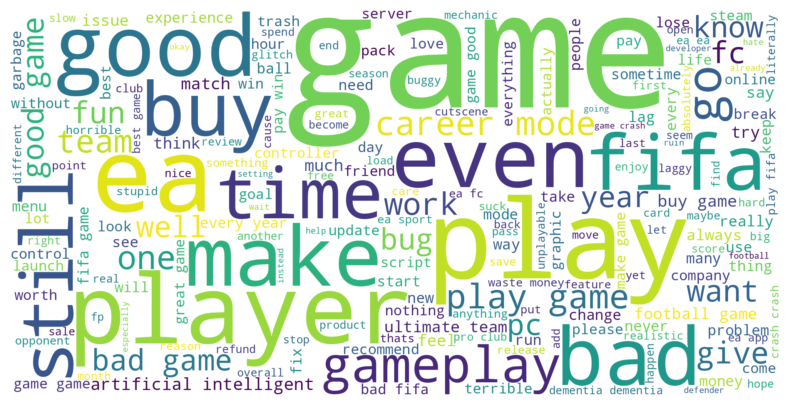

In [ ]:
# fc24
all_text = ' '.join(df_fc24['ReviewText'].tolist())

wordcloud = WordCloud(width=2000, height=1000, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

(-0.5, 1999.5, 999.5, -0.5)

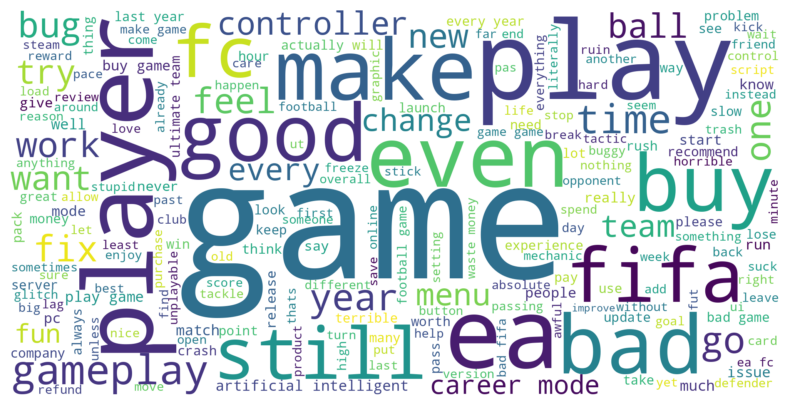

In [ ]:
# fc25
all_text = ' '.join(df_fc25['ReviewText'].tolist())

wordcloud = WordCloud(width=2000, height=1000, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

## Perbandingan Sebelum dan Sesudah Crosscheck Manual

In [ ]:
import matplotlib.pyplot as plt

def pie_charts_comparison(df_before, df_after, title):

    # Menghitung distribusi sentimen sebelum dan sesudah
    before_counts = df_before['Sentiment'].value_counts()
    after_counts = df_after['Sentiment'].value_counts()

    # Membuat pie chart
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Pie chart sebelum cross-check
    axs[0].pie(
        before_counts,
        labels=before_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    axs[0].set_title(f'{title} - Before')

    # Pie chart setelah cross-check
    axs[1].pie(
        after_counts,
        labels=after_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    axs[1].set_title(f'{title} - After')

    # Menambahkan super title untuk keseluruhan plot
    plt.suptitle(f'Perbandingan Sentimen {title}')
    plt.show()


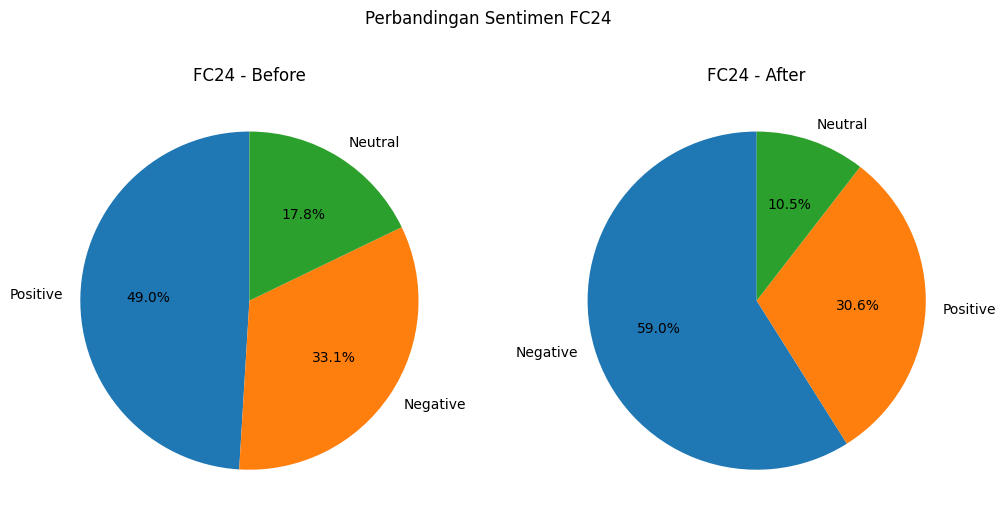

In [ ]:
pie_charts_comparison(df_b1, df_fc24, 'FC24')

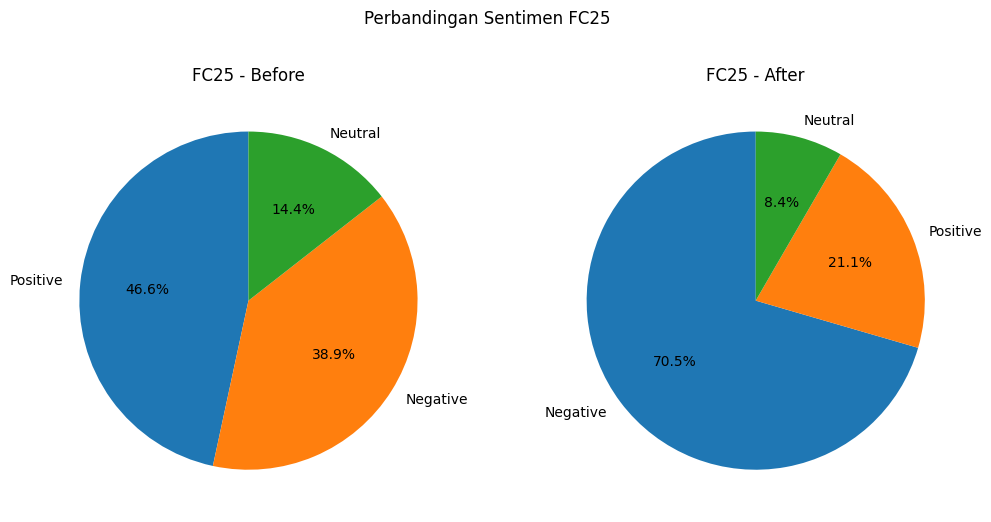

In [ ]:
pie_charts_comparison(df_b2, df_fc25, 'FC25')

## Perbandingan Review vs Sentimet

In [ ]:
# distribusi data
def create_grouped_pie_charts(df, game_name):
    review_counts = df['Review'].value_counts()
    sentiment_counts = df['Sentiment'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].pie(
        review_counts,
        labels=review_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66c2a5', '#fc8d62']
    )
    axes[0].set_title(f'Distribution Review {game_name}')

    axes[1].pie(
        sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#8da0cb', '#e78ac3', '#a6d854']
    )
    axes[1].set_title(f'Distribution Sentiment {game_name}')

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot untuk FC24
create_grouped_pie_charts(df_fc24, 'FC24')

In [ ]:
# Plot untuk FC25
create_grouped_pie_charts(df_fc25, 'FC25')

In [ ]:
# perbadingan
def plot_review_vs_sentiment(df, game_name):
    review_sentiment_distribution = df.groupby(['Review', 'Sentiment']).size().reset_index(name='Count')

    plt.figure(figsize=(10, 7))
    ax = sns.barplot(
        data=review_sentiment_distribution,
        x='Sentiment',
        y='Count',
        hue='Review',
        ci=None
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

    plt.title(f'Perbadingan Review vs Sentiment for {game_name}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.legend(title='Review')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot untuk FC24
plot_review_vs_sentiment(df_fc24, 'FC24')

In [ ]:
# Plot untuk FC25
plot_review_vs_sentiment(df_fc25, 'FC25')

## Jumlah Review berdasarkan Aspek


In [ ]:
def plot_review_count_by_aspect(df, game_name):
    aspect_review_count = df['AspectTerm'].value_counts().reset_index()
    aspect_review_count.columns = ['AspectTerm', 'Count']

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=aspect_review_count,
        x='Count',
        y='AspectTerm',
        palette='viridis')
    plt.title(f'Jumlah Review Berdasarkan Aspek - {game_name}')
    plt.xlabel('Jumlah Review')
    plt.ylabel('Aspek')
    plt.tight_layout()
    plt.show()

In [ ]:
plot_review_count_by_aspect(df_clean_fc24, 'FC24')

In [ ]:
plot_review_count_by_aspect(df_clean_fc25, 'FC25')

## Distribusi Sentiment Berdasarkan Aspek

In [ ]:
def plot_sentiment_by_aspect(df1, df2, aspect):
    df1_aspect = df1[df1['AspectTerm'] == aspect]
    df2_aspect = df2[df2['AspectTerm'] == aspect]

    sentiment_dist_fc24 = df1_aspect['Sentiment'].value_counts()
    sentiment_dist_fc25 = df2_aspect['Sentiment'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    # Pie chart untuk FC24
    axes[0].pie(
        sentiment_dist_fc24,
        labels=sentiment_dist_fc24.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66c2a5', '#fc8d62', '#8da0cb']
    )
    axes[0].set_title('FC 24')

    # Pie chart untuk FC25
    axes[1].pie(
        sentiment_dist_fc25,
        labels=sentiment_dist_fc25.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66c2a5', '#fc8d62', '#8da0cb']
    )
    axes[1].set_title('FC 25')
    fig.suptitle(f'{aspect}', fontsize=16)
    plt.tight_layout()
    plt.show()


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_sentiment_by_aspect_wc(df1, df2, aspect):
    # Filter data berdasarkan aspek
    df1_aspect = df1[df1['AspectTerm'] == aspect]
    df2_aspect = df2[df2['AspectTerm'] == aspect]

    # Gabungkan teks untuk WordCloud
    text_fc24 = ' '.join(df1_aspect['ReviewText'])
    text_fc25 = ' '.join(df2_aspect['ReviewText'])

    # Buat WordCloud
    wordcloud_fc24 = WordCloud(width=400, height=300, background_color='white').generate(text_fc24)
    wordcloud_fc25 = WordCloud(width=400, height=300, background_color='white').generate(text_fc25)

    # Plot WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # WordCloud untuk FC24
    axes[0].imshow(wordcloud_fc24, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('WordCloud FC 24')

    # WordCloud untuk FC25
    axes[1].imshow(wordcloud_fc25, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('WordCloud FC 25')

    # Add a main title
    fig.suptitle(f'WordCloud for Aspect: {aspect}', fontsize=16)
    plt.tight_layout()
    plt.show()


### Aspek Multiplayer Experience

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'multiplayer experience')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'multiplayer experience')

### Aspek Character

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'character')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'character')

### Aspek Gameplay

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'gameplay')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'gameplay')

### Aspek Sound/Audio

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'sound/audio')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'sound/audio')

### Aspek Visual

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'visual')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'visual')

### Aspek Game functionality/Bug

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'game functionality/bug')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'game functionality/bug')

### Aspek Price

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'price')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'price')

### Aspek Lain-Lain

In [ ]:
plot_sentiment_by_aspect(df_clean_fc24, df_clean_fc25, 'other')

In [ ]:
plot_sentiment_by_aspect_wc(df_clean_fc24, df_clean_fc25, 'other')

# Donwload df

In [ ]:
# concat
df_absa = pd.concat([df_clean_fc24, df_clean_fc25], ignore_index=True)
df = pd.concat([df_fc24, df_fc25], ignore_index=True)

In [ ]:
# df_absa.to_csv('df_absa.csv', index=False)
# df.to_csv('df.csv', index=False)